# CatBoost

At first, I thought about looking for any shortcomings in the previous two models and perhaps building additional features. But I decided to do this after boosting, so I could accurately compare the results of the folds and validation.

I want to try CatBoost on raw data first, as this model works well with categorical features, of which I have a sufficient number.

## Imports

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from heart_failure.dataset import split_data
from heart_failure.modeling.models import build_catboost_pipeline
from heart_failure.modeling.train import optuna_search, catboost_space
from heart_failure.config.modeling import CV_SPLITS, OPTUNA_N_TRIALS, F_BETA_THRESHOLD, MIN_RECALL
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE, CAT_FEATURES
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold
)
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.plots import plot_pr_curve

2026-06-19 14:41:44.163 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "catboost_raw"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

In [ ]:
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_catboost_pipeline,
    param_space=catboost_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_STATE,
    cat_features=CAT_FEATURES,
)

In [5]:
print_best_params(study)

Best parameters: {'model__iterations': 724, 'model__learning_rate': 0.007781471213526373, 'model__depth': 3, 'model__l2_leaf_reg': 0.007512012993863621, 'model__min_data_in_leaf': 25, 'model__subsample': 0.8270774171905173, 'model__rsm': 0.8131462500462147}
Best score: 0.93893


In [6]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
32,"{'model__iterations': 724, 'model__learning_ra...",0.027461,0.938933,0.933634,0.889887,0.942031,0.967209,0.961904,1
9,"{'model__iterations': 662, 'model__learning_ra...",0.022240,0.938837,0.931228,0.900960,0.941283,0.965276,0.955438,2
34,"{'model__iterations': 705, 'model__learning_ra...",0.029617,0.937988,0.933459,0.884493,0.942175,0.969195,0.960618,3
27,"{'model__iterations': 561, 'model__learning_ra...",0.027272,0.937930,0.931046,0.888628,0.945497,0.963169,0.961309,4
21,"{'model__iterations': 599, 'model__learning_ra...",0.022916,0.937570,0.920225,0.903491,0.941370,0.964133,0.958629,5


#### Feature importance

In [12]:
tree = model.named_steps["model"]
pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False)

ST_Slope          28.481587
ChestPainType     18.044739
Oldpeak           11.213646
Sex                9.267853
FastingBS          6.308976
Cholesterol        6.011337
RestingECG         4.977632
ExerciseAngina     4.949262
MaxHR              4.613469
Age                4.253030
RestingBP          1.878468
dtype: float64

Interestingly, ExerciseAngina has no more impact here than RestingECG. Judging by the transformed features, ExerciseAngina correlates with ChestPainType, ST_Slope, and Oldpeak. They are all at the top, so this situation is understandable.

### Threshold searching

In [9]:
y_val_proba = model.predict_proba(X_val)[:, 1]
best_threshold = find_best_threshold(y_val, y_val_proba, MIN_RECALL)
best_threshold

np.float64(0.341)

## Metrics

In [10]:
print("Train metrics")
y_train_proba = model.predict_proba(X_train)[:, 1]
y_train_pred = predict_by_threshold(model, X_train)
train_metrics = get_metrics(y_train, y_train_pred, y_train_proba)
train_metrics

Train metrics


precision    0.844444
recall       0.960674
f2_score     0.934937
pr_auc       0.964019
dtype: float64

In [11]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.770492
recall       0.959184
f2_score     0.914397
pr_auc       0.928390
dtype: float64

The metrics aren't significantly worse than on the train (except for precision). However, they're better than the previous models. The metrics on the cross-validation folds are also better. However, on fold (1), the score is worse than on the others (not only for this model, but for the others as well). It's interesting to understand why.

### Confusion Matrix

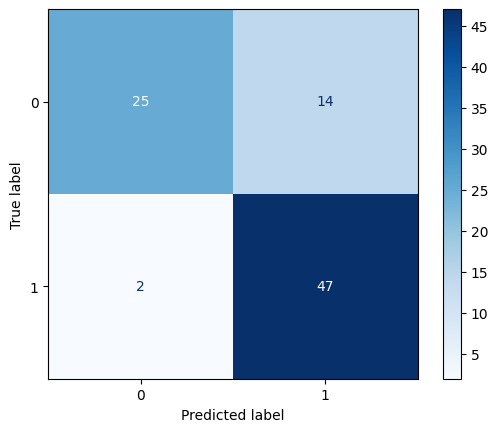

In [13]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

### PR-curve

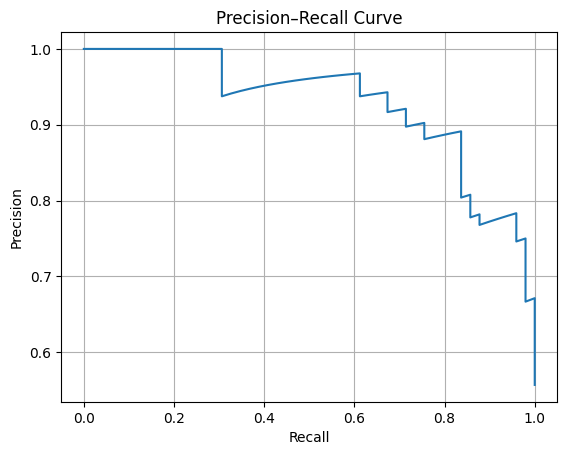

In [14]:
plot_pr_curve(y_val, y_val_proba)

### Test metrics

In [17]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.757576
recall       0.980392
f2_score     0.925926
pr_auc       0.923813
dtype: float64

As the next model, I want to look at XGBoost (with feature engineering, not without, as here) and compare the results.

In [ ]:
cv_results = optuna_cv_results_to_df(study)

with mlflow.start_run(run_name=MODEL_NAME) as run:
    best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
    mlflow.log_dict(best_cv_result, artifact_file="best_cv_result.json")
    for i in range(CV_SPLITS):
        mlflow.log_metric(f"cv_split_{i}_score", best_cv_result[f"split_test_{i}"])

    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", "all")
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(train_metrics, "train_")
    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")